# Import Dependencies

In [2]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import matplotlib.pyplot as plt
import pandas as pd

# Download the 'punkt_tab' data
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Frans\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# Define Document

In [3]:
sentence2 = """
Koalisi Selamatkan Pendidikan Indonesia (KOSPI) bersama para guru dan organisasi masyarakat sipil mengajukan Judicial Review UU APBN 2026 ke Mahkamah Konstitusi. Permohonan ini diajukan terkait penyelundupan kebijakan Program Makan Bergizi Gratis (MBG) yang dimasukkan ke dalam komponen anggaran pendidikan dan dinilai menggerus pendanaan penyelenggaraan pendidikan nasional, termasuk berdampak pada kesejahteraan guru dan kualitas pendidikan.

Daniel Winarta (Lembaga Bantuan Hukum Jakarta) menjelaskan bahwa permohonan uji materi diajukan terhadap Pasal 22 ayat (3) beserta Penjelasan Pasal 22 ayat (3) dalam UU APBN 2026. Dalam ketentuan Pasal 22 UU APBN tersebut, anggaran pendidikan mencapai lebih dari Rp769 triliun (20,0% dari keseluruhan APBN). Pasal 22 ayat (3) dan Penjelasannya memasukkan program makan bergizi (MBG) sebagai bagian dari pendanaan operasional pendidikan yang masuk dalam 20% APBN untuk pendidikan. Dalam Perpres 118 Tahun 2025, tertera bahwa dana sebesar Rp 223 triliun untuk Badan Gizi Nasional merupakan bagian dari anggaran pendidikan. Menurutnya, kebijakan ini menyimpang karena program yang tidak memiliki keterkaitan langsung dengan penyelenggaraan pendidikan dimasukkan dalam komponen anggaran pendidikan. Akibatnya, anggaran pendidikan bukan lagi 20%, melainkan menyisakan 14,2%. Hal ini menujukkan adanya pelanggaran UUD NRI 1945, yaitu berkaitan dengan Pasal 1 ayat (3), Pasal 28D ayat (1), Pasal 28D ayat (2), Pasal 31 ayat (1), dan Pasal 31 ayat (4) UUD NRI 1945.

Koalisi menilai pemerintah memaksakan program MBG masuk ke dalam komponen alokasi minimal 20% anggaran pendidikan, sehingga mengurangi ruang anggaran yang seharusnya digunakan untuk peningkatan kualitas pembelajaran dan kesejahteraan guru.

Reza Sudrajat (Guru Honorer) mengatakan, bahwa alasan dirinya menggugat adalah karena karir guru semakin tidak jelas, sementara program MBG disiapkan dengan ratusan triliun. Reza menyatakan, “Alokasi dana ini patut dipertanyakan apakah tepat sasaran atau justru menimbulkan korban lain. Di PPPK, teman-teman saya mengalami penurunan gaji signifikan, ada yang dari Rp2 juta menjadi Rp1 juta, bahkan hanya Rp100 ribu, sementara ada guru yang mendapat honor Rp400 ribu per bulan, apakah layak untuk hidup? Kondisi ini membuat profesi guru tidak menarik, sehingga muncul pertanyaan, siapa yang akan mengajar anak-anak kita kedepannya?” Reza mengatakan dirinya memberanikan diri menguji materi UU APBN demi masa depan pendidikan berkualitas bagi generasi mendatang.

Iman Zanatul Haeri (Perhimpunan Pendidikan dan Guru) menyatakan bahwa pelaksanaan anggaran pendidikan saat ini bermasalah. Penyaluran dana ke daerah pada APBN 2026 menurun drastis, dan berdampak pada lebih dari 500 kabupaten.

Kondisi ini memperburuk kesejahteraan guru, termasuk guru PPPK, dan guru PPPK Paruh Waktu yang masih menerima gaji rendah dan tidak memiliki jaminan tunjangan seperti THR. Di sisi lain, program MBG dinilai belum memiliki kajian yang memadai, menggangu pengajaran guru, menambah beban kerja guru, dan mengurangi jam belajar siswa. MBG tidak menyesuaikan kalender pendidikan dan kurikulum sekolah.

Berbagai fenomena intimidasi terhadap guru dan siswa yang memposting MBG, berpotensi mengganggu iklim demokrasi dalam sekolah. Iman menambahkan bahwa Pasal 1 UU Guru dan Dosen 14/2005 tugas guru adalah mendidik, membimbing, mengajar dan mengevaluasi siswa, bukan menjadi penanggung jawab MBG.

Sementara itu, Eva Nurcahyani (Indonesia Corruption Watch) menyoroti potensi persoalan tata kelola dalam implementasi program MBG . Ia menyebut terdapat indikasi keterlibatan afiliasi politik atau tim sukses dalam pengelolaan dapur MBG di daerah serta adanya kemudahan dalam proses pengadaan barang dan jasa karena program tersebut dikategorikan sebagai program strategis nasional. Kondisi ini membuka ruang penunjukan langsung dalam tender dan berpotensi mengurangi transparansi. Selain itu, pelaksanaan program MBG juga berdampak pada sekolah, seperti perubahan peran guru, potensi intimidasi, penambahan beban kerja pengawasan, serta gangguan terhadap proses pembelajaran.

Edy Kurniawan (Yayasan Lembaga Bantuan Hukum Indonesia) menambahkan bahwa konstruksi Pasal 22 ayat (3) dan penjelasannya dalam UU APBN 2026 menunjukkan pemerintah kembali memasukkan komponen di luar pendidikan ke dalam anggaran pendidikan. Padahal, Putusan Mahkamah Konstitusi telah menegaskan bahwa alokasi minimal 20% anggaran pendidikan bersifat imperatif dan tidak boleh dikurangi. Namun dalam praktiknya, realisasi anggaran pendidikan dinilai tidak sepenuhnya memenuhi kewajiban tersebut. Ini adalah bukti adanya upaya rekayasa anggaran dan penghindaran kewajiban konstitusional.

Selain bertentangan dengan Pasal 31 ayat (4) UUD 1945, kebijakan ini juga melanggar prinsip dasar hak asasi manusia , yaitu kewajiban negara menggunakan sumber daya yang tersedia secara optimal (maximum available resources), pemenuhan hak secara bertahap (progressive realization), serta larangan mengambil langkah mundur yang mengurangi pemenuhan hak yang telah ada (non-retrogression), termasuk hak atas pendidikan.

Busyro Muqoddas (Aktivis Muhammadiyah, Pemerhati Pendidikan) menilai pemerintah menjalankan program secara tertutup tanpa pelibatan masyarakat secara memadai . Kondisi ini mencerminkan pendekatan pragmatis yang minim transparansi dan akuntabilitas, serta berpotensi dimanfaatkan sebagai praktik politik uang terselubung menjelang agenda politik mendatang.

Oleh karenanya, Koalisi Selamatkan Pendidikan Indonesia (KOSPI) mengajak masyarakat, organisasi masyarakat sipil, serta media untuk bersama-sama mengawal proses Judicial Review UU APBN 2026 di Mahkamah Konstitusi guna memastikan anggaran pendidikan digunakan secara murni untuk penyelenggaraan pendidikan nasional.

Selain itu, ICW membuka kanal pengaduan konstitusional bagi guru di berbagai jenjang untuk mengawal pendanaan pendidikan, khususnya yang berkaitan dengan kesejahteraan guru. Informasi yang disampaikan akan digunakan sebagai bagian dari proses advokasi.
"""

# Text Preprocessing

In [4]:
# Sentence tokenization
sent_token2 = sent_tokenize(sentence2)
print("Tokenized sentences:")
for sent in sent_token2:
    print(sent)

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token2]
print("\nCleaned sentences (Indonesian stop words removed):")
for clean_sent in cleaned_sentences:
    print(clean_sent)



Tokenized sentences:

Koalisi Selamatkan Pendidikan Indonesia (KOSPI) bersama para guru dan organisasi masyarakat sipil mengajukan Judicial Review UU APBN 2026 ke Mahkamah Konstitusi.
Permohonan ini diajukan terkait penyelundupan kebijakan Program Makan Bergizi Gratis (MBG) yang dimasukkan ke dalam komponen anggaran pendidikan dan dinilai menggerus pendanaan penyelenggaraan pendidikan nasional, termasuk berdampak pada kesejahteraan guru dan kualitas pendidikan.
Daniel Winarta (Lembaga Bantuan Hukum Jakarta) menjelaskan bahwa permohonan uji materi diajukan terhadap Pasal 22 ayat (3) beserta Penjelasan Pasal 22 ayat (3) dalam UU APBN 2026.
Dalam ketentuan Pasal 22 UU APBN tersebut, anggaran pendidikan mencapai lebih dari Rp769 triliun (20,0% dari keseluruhan APBN).
Pasal 22 ayat (3) dan Penjelasannya memasukkan program makan bergizi (MBG) sebagai bagian dari pendanaan operasional pendidikan yang masuk dalam 20% APBN untuk pendidikan.
Dalam Perpres 118 Tahun 2025, tertera bahwa dana sebes

In [5]:
# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()  # Removed stop_words='english'
features = vectorizer.fit_transform(cleaned_sentences)

print("\nTF-IDF Feature Matrix (Sparse) on cleaned sentences:")
print(features)

print("\nShape of the Feature Matrix (Number of sentences, Number of unique words after Indonesian stop word removal):")
print(features.shape)

# To see the feature names (the words in the vocabulary after Indonesian stop word removal):
feature_names = vectorizer.get_feature_names_out()
print("\nFeature Names (Words in the vocabulary after Indonesian stop word removal):")
print(feature_names)

# To see the TF-IDF values for a specific cleaned sentence (e.g., the first):
if cleaned_sentences:
    first_cleaned_sentence_tfidf = features[0].toarray()
    print("\nTF-IDF values for the first cleaned sentence:")
    print(first_cleaned_sentence_tfidf)

    import pandas as pd
    def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
        """Returns a DataFrame of TF-IDF values for a given sentence."""
        sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
        tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
        tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
        return tfidf_df

    first_cleaned_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)
    print("\nTF-IDF values for the first cleaned sentence (sorted):")
    print(first_cleaned_sentence_tfidf_df)
else:
    print("\nNo cleaned sentences to process.")


TF-IDF Feature Matrix (Sparse) on cleaned sentences:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 586 stored elements and shape (35, 356)>
  Coords	Values
  (0, 136)	0.24092637827189586
  (0, 311)	0.2626046176739296
  (0, 253)	0.12351262438333849
  (0, 101)	0.2241114294459823
  (0, 143)	0.2626046176739296
  (0, 44)	0.2626046176739296
  (0, 86)	0.1465246127618222
  (0, 237)	0.2626046176739296
  (0, 161)	0.24092637827189586
  (0, 317)	0.2626046176739296
  (0, 191)	0.2931583800541473
  (0, 113)	0.2626046176739296
  (0, 295)	0.2626046176739296
  (0, 348)	0.18869437648964443
  (0, 25)	0.1798188535114605
  (0, 6)	0.21037261589167816
  (0, 155)	0.24092637827189586
  (0, 139)	0.24092637827189586
  (1, 253)	0.29909520671546774
  (1, 86)	0.1182734951500038
  (1, 271)	0.21197234641604698
  (1, 64)	0.21197234641604698
  (1, 331)	0.23663509896373783
  (1, 267)	0.23663509896373783
  (1, 124)	0.1944738450076535
  :	:
  (32, 195)	0.18125746479526428
  (32, 169)	0.20234657418736077
  

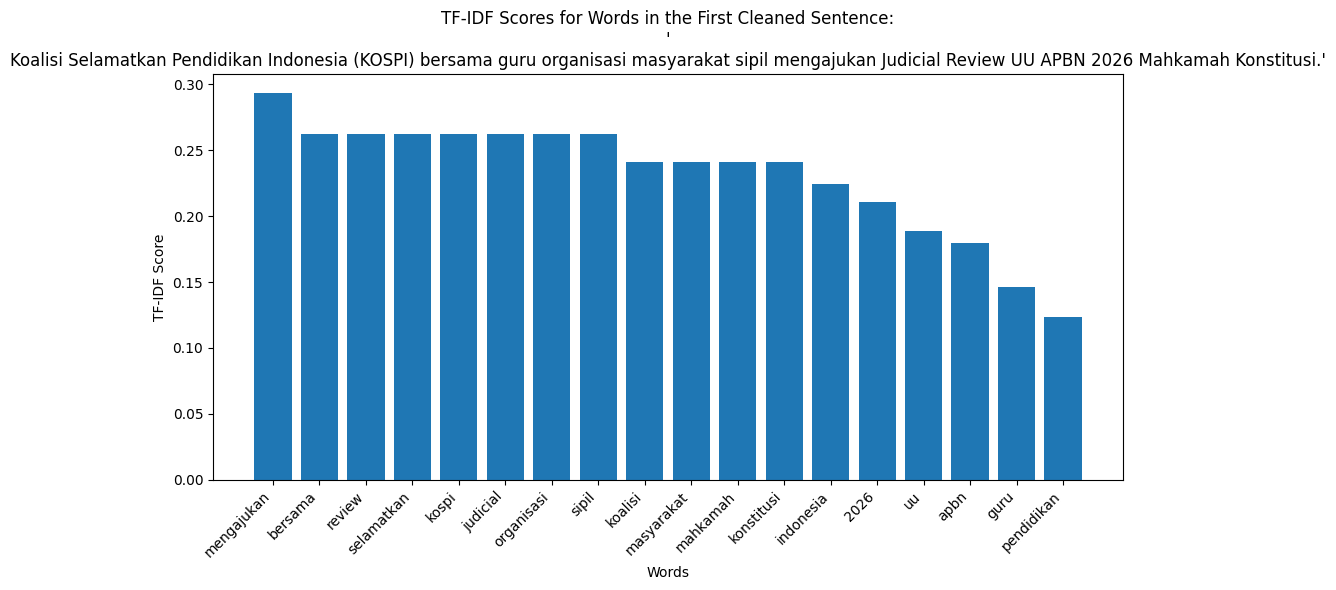

In [6]:

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)
feature_names = vectorizer.get_feature_names_out()

# Get TF-IDF scores for the first cleaned sentence
if cleaned_sentences:
    first_cleaned_sentence = cleaned_sentences[0]
    first_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)

    # Visualize the TF-IDF scores as a histogram
    plt.figure(figsize=(10, 6))
    plt.bar(first_sentence_tfidf_df['Feature'], first_sentence_tfidf_df['TF-IDF'])
    plt.xlabel("Words")
    plt.ylabel("TF-IDF Score")
    plt.title(f"TF-IDF Scores for Words in the First Cleaned Sentence:\n'{first_cleaned_sentence}'")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No cleaned sentences to visualize.")

# Calculate Sentence Score

**List of Sentences:**
1. 
Koalisi Selamatkan Pendidikan Indonesia (KOSPI) bersama para guru dan organisasi masyarakat sipil mengajukan Judicial Review UU APBN 2026 ke Mahkamah Konstitusi.
2. Permohonan ini diajukan terkait penyelundupan kebijakan Program Makan Bergizi Gratis (MBG) yang dimasukkan ke dalam komponen anggaran pendidikan dan dinilai menggerus pendanaan penyelenggaraan pendidikan nasional, termasuk berdampak pada kesejahteraan guru dan kualitas pendidikan.
3. Daniel Winarta (Lembaga Bantuan Hukum Jakarta) menjelaskan bahwa permohonan uji materi diajukan terhadap Pasal 22 ayat (3) beserta Penjelasan Pasal 22 ayat (3) dalam UU APBN 2026.
4. Dalam ketentuan Pasal 22 UU APBN tersebut, anggaran pendidikan mencapai lebih dari Rp769 triliun (20,0% dari keseluruhan APBN).
5. Pasal 22 ayat (3) dan Penjelasannya memasukkan program makan bergizi (MBG) sebagai bagian dari pendanaan operasional pendidikan yang masuk dalam 20% APBN untuk pendidikan.
6. Dalam Perpres 118 Tahun 2025, tert

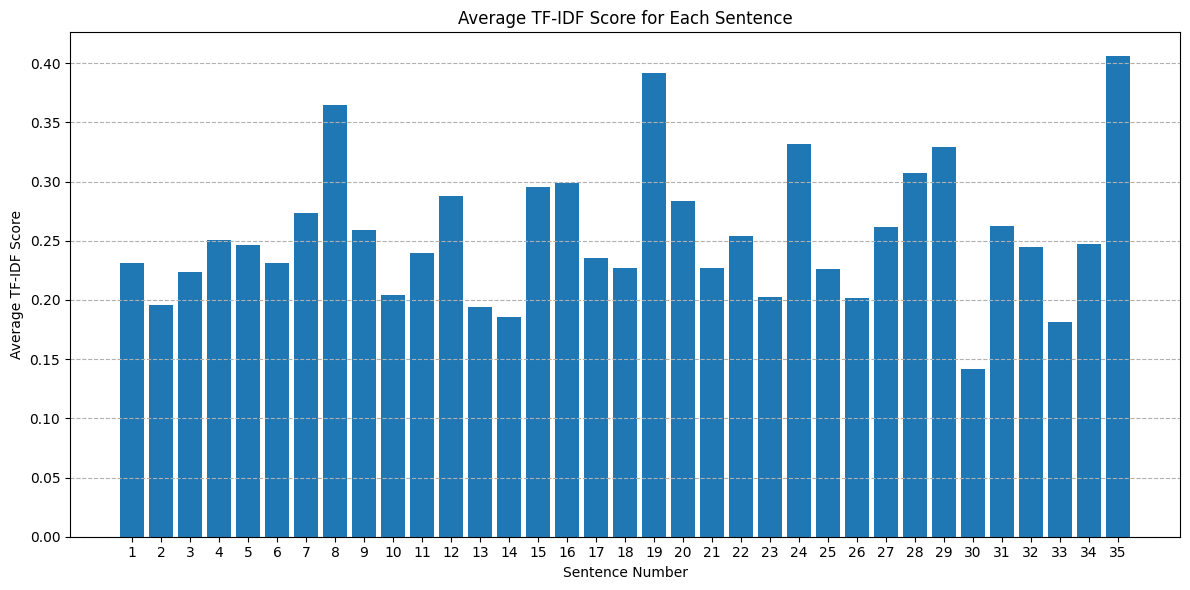


**Explanation of the Histogram :**
Imagine we've given each sentence in the news article a score based on the importance of the words it contains. This score is called the 'Average TF-IDF Score'.

The histogram above is like a bar chart that shows this score for each sentence:
- **The horizontal line (Sentence Number):** Each number on this line represents a different sentence in the article, starting from the first sentence (1) to the last.
- **The vertical bar for each sentence:** The height of each bar shows the 'Average TF-IDF Score' for that particular sentence.

**What does the height of the bar tell us?**
- **Taller bar:** A taller bar means the sentence contains words that are considered more important and unique within the entire article. These sentences likely carry more key information.
- **Shorter bar:** A shorter bar means the sentence contains words that are either less important or more common throughout the article. These sentences might be supporting details or less c

In [7]:

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

# Variable initialization
sent_index = 0
sent_scores = []

# Calculate sentence TF-IDF score and list sentences
print("**List of Sentences:**")
for i, sent in enumerate(sent_token2):
    print(f"{i + 1}. {sent}")
print("\n-------------------------")

# Calculate average TF-IDF score for each sentence
print("\n**Average TF-IDF Score for Each Sentence:**")
for i in features:
    print(f"- Sentence {sent_index + 1}")
    sent_score = i.sum()
    sent_length = len(i.data)
    print("  Sum of TF-IDF scores:", sent_score)
    print("  Number of words:", sent_length)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    print("  Average TF-IDF score:", avg_score)
    sent_scores.append(avg_score)
    sent_index += 1
print("\n-------------------------")

print("\nList of average TF-IDF scores for each sentence:")
print(sent_scores)

# Visualize the average TF-IDF scores as a histogram
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(sent_scores) + 1), sent_scores)
plt.xlabel("Sentence Number")
plt.ylabel("Average TF-IDF Score")
plt.title("Average TF-IDF Score for Each Sentence")
plt.xticks(range(1, len(sent_scores) + 1))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Explanation:
print("\n**Explanation of the Histogram :**")
print("Imagine we've given each sentence in the news article a score based on the importance of the words it contains. This score is called the 'Average TF-IDF Score'.")
print("\nThe histogram above is like a bar chart that shows this score for each sentence:")
print("- **The horizontal line (Sentence Number):** Each number on this line represents a different sentence in the article, starting from the first sentence (1) to the last.")
print("- **The vertical bar for each sentence:** The height of each bar shows the 'Average TF-IDF Score' for that particular sentence.")
print("\n**What does the height of the bar tell us?**")
print("- **Taller bar:** A taller bar means the sentence contains words that are considered more important and unique within the entire article. These sentences likely carry more key information.")
print("- **Shorter bar:** A shorter bar means the sentence contains words that are either less important or more common throughout the article. These sentences might be supporting details or less central to the main topic.")
print("\nSo, by looking at this chart, you can quickly get a sense of which sentences in the article are likely to be the most informative based on the words they use.")

# Define Threshold

In [8]:
# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

# Variable initialization
sent_index = 0
sent_scores = []

# Calculate sentence TF-IDF score
for i in features:
    sent_score = i.sum()
    sent_length = len(i.data)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sent_scores.append(avg_score)

# Calculate the average of all sentence scores (threshold)
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print("Threshold (Average of Sentence Scores):", threshold)

Threshold (Average of Sentence Scores): 0.25540396350451117


In [9]:
import nltk
from nltk.tokenize import word_tokenize
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import math

# Download the 'punkt' data if needed
try:
    nltk.data.find('tokenizers/punkt/PY3/english.pickle')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

sentences = []

for i, sent in enumerate(sent_token2):
    sentences.append(sent)

print("Tokenized sentences:")
for sent in sentences:
    print(sent)

# Initialize a list to store cleaned sentences
all_cleaned_sentences = []
for sentence in sentences:
    cleaned_sentence = stopword_remover.remove(sentence)
    all_cleaned_sentences.append(cleaned_sentence)

# Function to calculate TF for a term in a document
def calculate_tf(term, document):
    words = word_tokenize(document.lower())
    return words.count(term) / len(words) if len(words) > 0 else 0

# Function to calculate IDF for a term across all documents
def calculate_idf(term, all_documents):
    num_documents_with_term = sum(1 for doc in all_documents if term.lower() in word_tokenize(doc.lower()))
    if num_documents_with_term > 0:
        return math.log(len(all_documents) / num_documents_with_term)
    else:
        return 0

# Calculate TF-IDF for "mengajukan" in each sentence
tfidf_scores = {}
for i, sentence in enumerate(sentences):
    cleaned_sentence = stopword_remover.remove(sentence)
    tf = calculate_tf("mengajukan", cleaned_sentence)
    idf = calculate_idf("mengajukan", all_cleaned_sentences)
    tfidf = tf * idf
    tfidf_scores[f"Sentence {i+1}"] = tfidf

# Print the TF-IDF scores for "mengajukan" in each sentence
print("TF-IDF Score for 'mengajukan' in each cleaned sentence:")
for sentence_num, score in tfidf_scores.items():
    print(f"{sentence_num}: {score:.4f}")

# Calculate the overall IDF for "mengajukan" across all cleaned sentences
overall_idf_mengajukan = calculate_idf("mengajukan", all_cleaned_sentences)
print(f"\nOverall IDF for 'mengajukan': {overall_idf_mengajukan:.4f}")

Tokenized sentences:

Koalisi Selamatkan Pendidikan Indonesia (KOSPI) bersama para guru dan organisasi masyarakat sipil mengajukan Judicial Review UU APBN 2026 ke Mahkamah Konstitusi.
Permohonan ini diajukan terkait penyelundupan kebijakan Program Makan Bergizi Gratis (MBG) yang dimasukkan ke dalam komponen anggaran pendidikan dan dinilai menggerus pendanaan penyelenggaraan pendidikan nasional, termasuk berdampak pada kesejahteraan guru dan kualitas pendidikan.
Daniel Winarta (Lembaga Bantuan Hukum Jakarta) menjelaskan bahwa permohonan uji materi diajukan terhadap Pasal 22 ayat (3) beserta Penjelasan Pasal 22 ayat (3) dalam UU APBN 2026.
Dalam ketentuan Pasal 22 UU APBN tersebut, anggaran pendidikan mencapai lebih dari Rp769 triliun (20,0% dari keseluruhan APBN).
Pasal 22 ayat (3) dan Penjelasannya memasukkan program makan bergizi (MBG) sebagai bagian dari pendanaan operasional pendidikan yang masuk dalam 20% APBN untuk pendidikan.
Dalam Perpres 118 Tahun 2025, tertera bahwa dana sebes

In [ ]:
#threshold = sum(sent_scores)/len(sent_scores) # Average of Sentence Scores
#threshold

np.float64(0.22305438878724734)

# Get Sentences

In [10]:
# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token2]

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

# Variable initialization
sent_index = 0
sent_scores = []

# Calculate average TF-IDF score for each sentence
for i in features:
    sent_score = i.sum()
    sent_length = len(i.data)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sent_scores.append(avg_score)

# Calculate the average of all sentence scores (threshold)
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print("Threshold (Average of Sentence Scores):", threshold)

# Final summary initialization
final_summ = ""

# Get summary sentences
print("\n**Summary Sentences (above or equal to the threshold):**")
for index, data in enumerate(sent_scores):
    if data >= threshold:
        final_summ = final_summ + " " + sent_token2[index]
        print(f"- {sent_token2[index]}")

print("\n**Final Summary:**")
print(final_summ.strip())

Threshold (Average of Sentence Scores): 0.25540396350451117

**Summary Sentences (above or equal to the threshold):**
- Menurutnya, kebijakan ini menyimpang karena program yang tidak memiliki keterkaitan langsung dengan penyelenggaraan pendidikan dimasukkan dalam komponen anggaran pendidikan.
- Akibatnya, anggaran pendidikan bukan lagi 20%, melainkan menyisakan 14,2%.
- Hal ini menujukkan adanya pelanggaran UUD NRI 1945, yaitu berkaitan dengan Pasal 1 ayat (3), Pasal 28D ayat (1), Pasal 28D ayat (2), Pasal 31 ayat (1), dan Pasal 31 ayat (4) UUD NRI 1945.
- Reza menyatakan, “Alokasi dana ini patut dipertanyakan apakah tepat sasaran atau justru menimbulkan korban lain.
- Iman Zanatul Haeri (Perhimpunan Pendidikan dan Guru) menyatakan bahwa pelaksanaan anggaran pendidikan saat ini bermasalah.
- Penyaluran dana ke daerah pada APBN 2026 menurun drastis, dan berdampak pada lebih dari 500 kabupaten.
- MBG tidak menyesuaikan kalender pendidikan dan kurikulum sekolah.
- Berbagai fenomena intimi

In [12]:
# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Function to calculate TF for a term in a document
def calculate_tf(term, document):
    words = word_tokenize(document.lower())
    return words.count(term) / len(words) if len(words) > 0 else 0

# Function to calculate IDF for a term across all documents
def calculate_idf(term, all_documents):
    num_documents_with_term = sum(1 for doc in all_documents if term.lower() in word_tokenize(doc.lower()))
    if num_documents_with_term > 0:
        return math.log(len(all_documents) / num_documents_with_term)
    else:
        return 0

# Calculate TF-IDF for "mengajukan" in each sentence
tfidf_scores = {}
all_cleaned_sentences = []

for i, sentence in enumerate(sentences):
    cleaned_sentence = stopword_remover.remove(sentence)
    all_cleaned_sentences.append(cleaned_sentence)
    tf = calculate_tf("mengajukan", cleaned_sentence)
    idf = calculate_idf("mengajukan", all_cleaned_sentences)
    tfidf = tf * idf
    tfidf_scores[f"Sentence {i+1}"] = tfidf

# Print the TF-IDF scores for "mengajukan" in each sentence
print("TF-IDF Score for 'mengajukan' in each sentence:")
for sentence_num, score in tfidf_scores.items():
    print(f"{sentence_num}: {score:.4f}")

# Calculate the overall IDF for "mengajukan" across all cleaned sentences
overall_idf_mengajukan = calculate_idf("mengajukan", all_cleaned_sentences)
print(f"\nOverall IDF for 'mengajukan': {overall_idf_mengajukan:.4f}")

# You can also use scikit-learn's TfidfVectorizer for a more direct approach:
vectorizer = TfidfVectorizer(stop_words=factory.get_stop_words())
tfidf_matrix = vectorizer.fit_transform(sentences)
feature_names = vectorizer.get_feature_names_out()

try:
    mengajukan_index = list(feature_names).index("mengajukan")
    print("\nTF-IDF Score for 'mengajukan' using TfidfVectorizer:")
    for i, sentence in enumerate(sentences):
        tfidf = tfidf_matrix[i, mengajukan_index]
        print(f"Sentence {i+1}: {tfidf:.4f}")
except ValueError:
    print("\n'mengajukan' not found in the vocabulary after stop word removal by TfidfVectorizer.")

TF-IDF Score for 'mengajukan' in each sentence:
Sentence 1: 0.0000
Sentence 2: 0.0000
Sentence 3: 0.0000
Sentence 4: 0.0000
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.0000
Sentence 10: 0.0000
Sentence 11: 0.0000
Sentence 12: 0.0000
Sentence 13: 0.0000
Sentence 14: 0.0000
Sentence 15: 0.0000
Sentence 16: 0.0000
Sentence 17: 0.0000
Sentence 18: 0.0000
Sentence 19: 0.0000
Sentence 20: 0.0000
Sentence 21: 0.0000
Sentence 22: 0.0000
Sentence 23: 0.0000
Sentence 24: 0.0000
Sentence 25: 0.0000
Sentence 26: 0.0000
Sentence 27: 0.0000
Sentence 28: 0.0000
Sentence 29: 0.0000
Sentence 30: 0.0000
Sentence 31: 0.0000
Sentence 32: 0.0000
Sentence 33: 0.0000
Sentence 34: 0.0000
Sentence 35: 0.0000

Overall IDF for 'mengajukan': 3.5553

TF-IDF Score for 'mengajukan' using TfidfVectorizer:
Sentence 1: 0.2932
Sentence 2: 0.0000
Sentence 3: 0.0000
Sentence 4: 0.0000
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.000

In [13]:
final_summ

' Menurutnya, kebijakan ini menyimpang karena program yang tidak memiliki keterkaitan langsung dengan penyelenggaraan pendidikan dimasukkan dalam komponen anggaran pendidikan. Akibatnya, anggaran pendidikan bukan lagi 20%, melainkan menyisakan 14,2%. Hal ini menujukkan adanya pelanggaran UUD NRI 1945, yaitu berkaitan dengan Pasal 1 ayat (3), Pasal 28D ayat (1), Pasal 28D ayat (2), Pasal 31 ayat (1), dan Pasal 31 ayat (4) UUD NRI 1945. Reza menyatakan, “Alokasi dana ini patut dipertanyakan apakah tepat sasaran atau justru menimbulkan korban lain. Iman Zanatul Haeri (Perhimpunan Pendidikan dan Guru) menyatakan bahwa pelaksanaan anggaran pendidikan saat ini bermasalah. Penyaluran dana ke daerah pada APBN 2026 menurun drastis, dan berdampak pada lebih dari 500 kabupaten. MBG tidak menyesuaikan kalender pendidikan dan kurikulum sekolah. Berbagai fenomena intimidasi terhadap guru dan siswa yang memposting MBG, berpotensi mengganggu iklim demokrasi dalam sekolah. Kondisi ini membuka ruang pen

In [14]:
# Final summary initialization
final_summ = ""

# Get summary sentences
for index, data in enumerate(sent_scores) :
  if (data >= (threshold)) :
    final_summ = final_summ + " " + sent_token2[index]
    print("- ", sent_token2[index])

-  Menurutnya, kebijakan ini menyimpang karena program yang tidak memiliki keterkaitan langsung dengan penyelenggaraan pendidikan dimasukkan dalam komponen anggaran pendidikan.
-  Akibatnya, anggaran pendidikan bukan lagi 20%, melainkan menyisakan 14,2%.
-  Hal ini menujukkan adanya pelanggaran UUD NRI 1945, yaitu berkaitan dengan Pasal 1 ayat (3), Pasal 28D ayat (1), Pasal 28D ayat (2), Pasal 31 ayat (1), dan Pasal 31 ayat (4) UUD NRI 1945.
-  Reza menyatakan, “Alokasi dana ini patut dipertanyakan apakah tepat sasaran atau justru menimbulkan korban lain.
-  Iman Zanatul Haeri (Perhimpunan Pendidikan dan Guru) menyatakan bahwa pelaksanaan anggaran pendidikan saat ini bermasalah.
-  Penyaluran dana ke daerah pada APBN 2026 menurun drastis, dan berdampak pada lebih dari 500 kabupaten.
-  MBG tidak menyesuaikan kalender pendidikan dan kurikulum sekolah.
-  Berbagai fenomena intimidasi terhadap guru dan siswa yang memposting MBG, berpotensi mengganggu iklim demokrasi dalam sekolah.
-  Kond

# Summarization Result

In [15]:
final_summ

' Menurutnya, kebijakan ini menyimpang karena program yang tidak memiliki keterkaitan langsung dengan penyelenggaraan pendidikan dimasukkan dalam komponen anggaran pendidikan. Akibatnya, anggaran pendidikan bukan lagi 20%, melainkan menyisakan 14,2%. Hal ini menujukkan adanya pelanggaran UUD NRI 1945, yaitu berkaitan dengan Pasal 1 ayat (3), Pasal 28D ayat (1), Pasal 28D ayat (2), Pasal 31 ayat (1), dan Pasal 31 ayat (4) UUD NRI 1945. Reza menyatakan, “Alokasi dana ini patut dipertanyakan apakah tepat sasaran atau justru menimbulkan korban lain. Iman Zanatul Haeri (Perhimpunan Pendidikan dan Guru) menyatakan bahwa pelaksanaan anggaran pendidikan saat ini bermasalah. Penyaluran dana ke daerah pada APBN 2026 menurun drastis, dan berdampak pada lebih dari 500 kabupaten. MBG tidak menyesuaikan kalender pendidikan dan kurikulum sekolah. Berbagai fenomena intimidasi terhadap guru dan siswa yang memposting MBG, berpotensi mengganggu iklim demokrasi dalam sekolah. Kondisi ini membuka ruang pen